In [138]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import matplotlib as plt

In [139]:
import openseespy.opensees as ops
import opsvis as opsv
import matplotlib.pyplot as plt

# -----------------------------
# Model Initialization
# -----------------------------
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)

# -----------------------------
# Nodes
# -----------------------------
ops.node(1, 0.0, 0.0)
ops.node(2, 4.0, 0.0)
ops.node(3, 9.0, 0.0)

# -----------------------------
# Boundary Conditions
# -----------------------------
ops.fix(1, 1, 1, 0)
ops.fix(2, 0, 1, 0)

# -----------------------------
# Geometry Transformation
# -----------------------------
ops.geomTransf('Linear', 1)

# -----------------------------
# Elements
# -----------------------------
A = 0.002
E = 200e9
Iz = 1.6e-5

# Element 1 (no release)
ops.element('elasticBeamColumn', 1, 1, 2, A, E, Iz, 1)

# Element 2 with release at end 2 (node 3)
ops.element('elasticBeamColumn', 2, 2, 3, A, E, Iz, 1)

# -----------------------------
# Time Series and Load Pattern
# -----------------------------
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)

# Point load at node 3
ops.load(3, 0.0, 2000.0, 0.0)

# Trapezoidal distributed load on element 2
# Using beamUniform with 6 args: Wy1 Wx1 aL bL Wy2 Wx2
ops.eleLoad('-ele', 2, '-type', 'beamUniform',
            -2000.0, 0.0, 0.2, 0.9, -4000.0, 0.0)
ops.eleLoad('-ele', 1, '-type', 'beamUniform',
            -2000.0, 0.0)

# -----------------------------
# Analysis
# -----------------------------
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.test('NormDispIncr', 1e-6, 6, 2)
ops.algorithm('Linear')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')
ops.analyze(100)


# -----------------------------
# Print End Moments to Verify
# -----------------------------
print("Element 2 forces (local):", ops.eleForce(2))


Element 2 forces (local): [0.0, 8500.0, 20916.666666666668, 0.0, 1999.999999999999, -9.094947017729282e-13]


<Axes: >

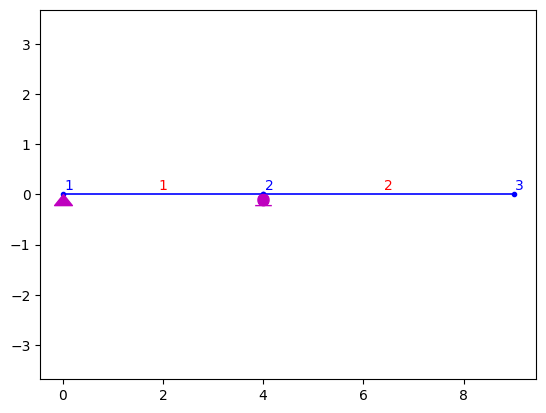

In [140]:



opsv.plot_model()
# plt.title('plot_model before defining elements')
# plt.show()

In [141]:



ops.printModel()


Current Domain Information
	Current Time: 100
	Committed Time: 100
NODE DATA: NumNodes: 3

numComponents: 3

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 0.00269097 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 5 


 Node: 2
	Coordinates  : 4 0 
	Disps: 0 0 -0.00704861 
	 unbalanced Load: 0 0 0 
	ID : 3 -1 4 


 Node: 3
	Coordinates  : 9 0 
	Disps: 0 -0.0697974 -0.0150727 
	 unbalanced Load: 0 2000 0 
	ID : 0 1 2 

ELEMENT DATA: NumEle: 2

numComponents: 2

ElasticBeam2d: 1
	Connected Nodes: 1 2 
	CoordTransf: 1
	mass density:  0, cMass: 0
	release code:  0
	End 1 Forces (P V M): 0 -1229.17 2.27374e-12
	End 2 Forces (P V M): 0 9229.17 -20916.7

ElasticBeam2d: 2
	Connected Nodes: 2 3 
	CoordTransf: 1
	mass density:  0, cMass: 0
	release code:  0
	End 1 Forces (P V M): 0 8500 20916.7
	End 2 Forces (P V M): 0 2000 -9.09495e-13

SP_Constraints: numConstraints: 3

numComponents: 3
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current value: 0
SP_Constraint: 1	 Node: 1 DOF: 2 ref value: 0 current valu

<Axes: >

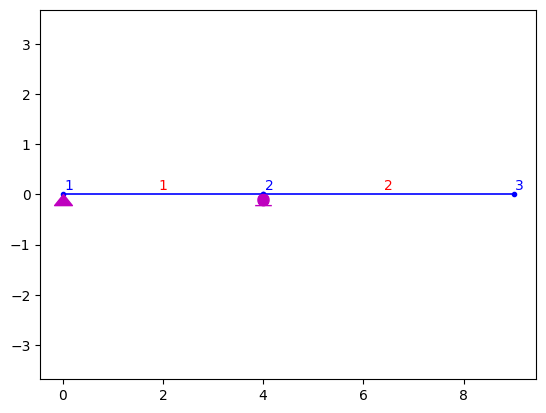

In [142]:

opsv.plot_model()
# plt.title('plot_model after defining elements')


<Axes: >

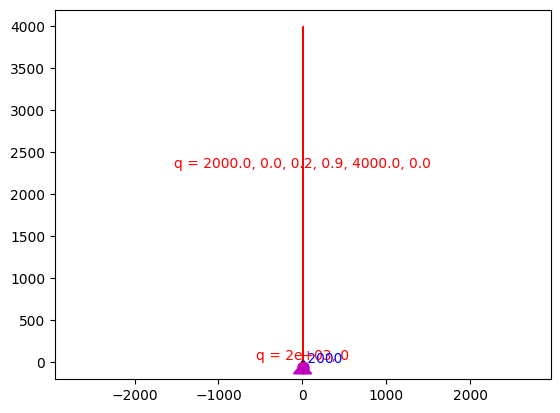

In [143]:
opsv.plot_load()

# sfac = 80.


np.float64(12.89445987815059)

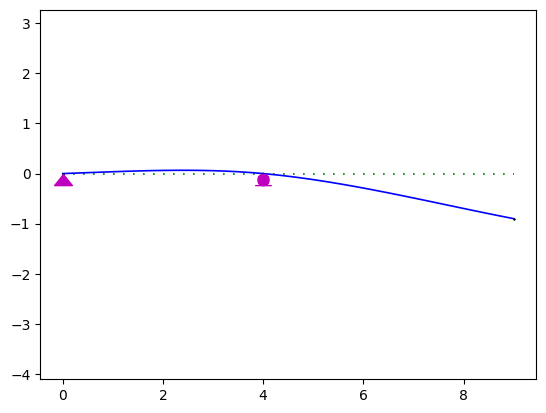

In [144]:

opsv.plot_defo()
# opsv.plot_defo(sfac)
# fmt_interp = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
# opsv.plot_defo(sfac, fmt_interp=fmt_interp)


(np.float64(-0.0), np.float64(-0.0), <Axes: >)

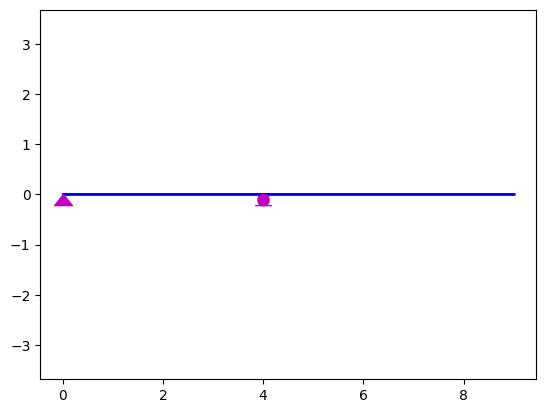

In [145]:

# 4. plot N, V, M forces diagrams

sfacN, sfacV, sfacM = 5.e-4, 5.e-4, 5.e-4

opsv.section_force_diagram_2d('N', sfacN)
# plt.title('Axial force distribution')


(np.float64(-2000.0), np.float64(8500.0), <Axes: >)

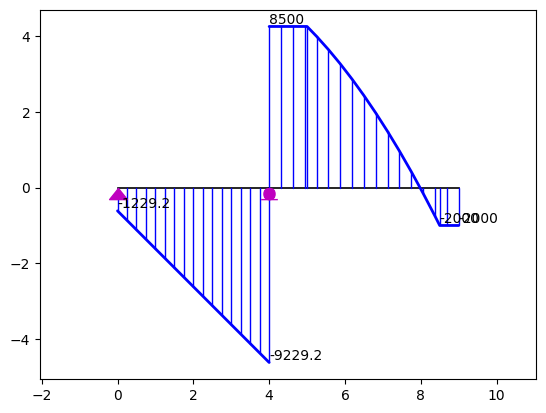

In [146]:

opsv.section_force_diagram_2d('T', sfacV)
# plt.title('Shear force distribution')


(np.float64(-20916.666666666668), np.float64(1500.162760416666), <Axes: >)

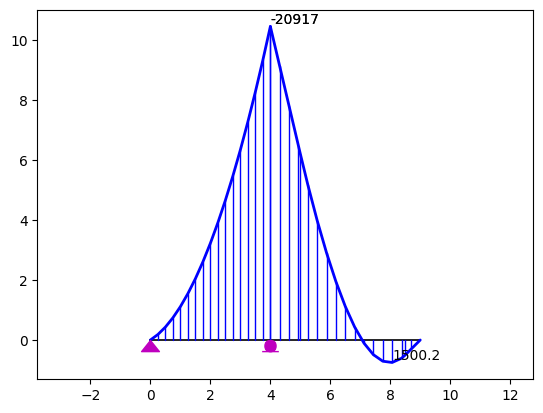

In [147]:

opsv.section_force_diagram_2d('M', sfacM)
# plt.title('Bending moment distribution')


In [148]:
import numpy as np

In [149]:
# ele_node_tags = ops.eleNodes(2)
# sfac = 2
# nen = len(ele_node_tags)
# ndf = 2
# ecrd = np.zeros((nen, 2))
# ed = np.zeros((nen, ndf))

# ele_node_tags = ops.eleNodes(2)
# print(ele_node_tags)
# for i, ele_node_tag in enumerate(ele_node_tags):
#     ecrd[i, :] = ops.nodeCoord(ele_node_tag)

# for i, ele_node_tag in enumerate(ele_node_tags):
#     ed[i, :] = ops.nodeDisp(ele_node_tag)[:2]
# print(ecrd)
# print(ed)

# xy = ecrd + sfac * ed
# print("xy ", xy)
# fig, ax = plt.pyplot.subplots()
# fmt_defo={'color': 'red', 'linestyle': 'dashed', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
# ax.plot(xy[:, 0], xy[:, 1],**fmt_defo)

In [150]:
ele_node_tags = ops.eleNodes(2)
sfac = 2
nen = len(ele_node_tags)
ndf = 3
ecrd_nodes = np.zeros((nen, 2))
ed = np.zeros((nen, ndf))
for i, ele_node_tag in enumerate(ele_node_tags):
    # ecrd[i, :] = ops.nodeCoord(ele_node_tag)
    ecrd_nodes[i, :] = ops.nodeCoord(ele_node_tag)
print(ecrd_nodes)
ecrd_eles0 = np.copy(ecrd_nodes)
ecrd_eles = np.copy(ecrd_nodes)
for i, ele_node_tag in enumerate(ele_node_tags):
    ed[i, :] = ops.nodeDisp(ele_node_tag)
print(ed)
print(ed.flatten())
G, L, cosa, cosb = opsv.opsvmodel.rot_transf_2d(ecrd)
print(" G ",G," L ",L," cosa ",cosa," cosb ",cosb)
u_l = G @ ed.flatten()
print("ul ",u_l)

[[4. 0.]
 [9. 0.]]
[[ 0.          0.         -0.00704861]
 [ 0.         -0.06979742 -0.0150727 ]]
[ 0.          0.         -0.00704861  0.         -0.06979742 -0.0150727 ]
 G  [[ 1.  0.  0.  0.  0.  0.]
 [-0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0. -0.  1.  0.]
 [ 0.  0.  0.  0.  0.  1.]]  L  5.0  cosa  1.0  cosb  0.0
ul  [ 0.          0.         -0.00704861  0.         -0.06979742 -0.0150727 ]


In [151]:
L = 5
nep = 17
xl = np.linspace(0., 5, num=nep)
one = np.ones(xl.shape)
N_t = np.column_stack((one - 3 * xl**2 / L**2 + 2 * xl**3 / L**3,
                        xl - 2 * xl**2 / L + xl**3 / L**2,
                        3 * xl**2 / L**2 - 2 * xl**3 / L**3,
                        -xl**2 / L + xl**3 / L**2))
print(N_t.shape)
print(N_t)

(17, 4)
[[ 1.          0.          0.          0.        ]
 [ 0.98876953  0.2746582   0.01123047 -0.01831055]
 [ 0.95703125  0.47851562  0.04296875 -0.06835938]
 [ 0.90771484  0.61889648  0.09228516 -0.14282227]
 [ 0.84375     0.703125    0.15625    -0.234375  ]
 [ 0.76806641  0.73852539  0.23193359 -0.33569336]
 [ 0.68359375  0.73242188  0.31640625 -0.43945312]
 [ 0.59326172  0.69213867  0.40673828 -0.53833008]
 [ 0.5         0.625       0.5        -0.625     ]
 [ 0.40673828  0.53833008  0.59326172 -0.69213867]
 [ 0.31640625  0.43945312  0.68359375 -0.73242188]
 [ 0.23193359  0.33569336  0.76806641 -0.73852539]
 [ 0.15625     0.234375    0.84375    -0.703125  ]
 [ 0.09228516  0.14282227  0.90771484 -0.61889648]
 [ 0.04296875  0.06835938  0.95703125 -0.47851562]
 [ 0.01123047  0.01831055  0.98876953 -0.2746582 ]
 [ 0.          0.          1.          0.        ]]


In [152]:
xl = np.linspace(0., L, num=nep)
one = np.ones(xl.shape)
N_a = np.column_stack((one - xl / L, xl / L))

print(N_a.shape)
print(N_a)

(17, 2)
[[1.     0.    ]
 [0.9375 0.0625]
 [0.875  0.125 ]
 [0.8125 0.1875]
 [0.75   0.25  ]
 [0.6875 0.3125]
 [0.625  0.375 ]
 [0.5625 0.4375]
 [0.5    0.5   ]
 [0.4375 0.5625]
 [0.375  0.625 ]
 [0.3125 0.6875]
 [0.25   0.75  ]
 [0.1875 0.8125]
 [0.125  0.875 ]
 [0.0625 0.9375]
 [0.     1.    ]]


In [153]:
ele_offsets = np.array(ops.eleResponse(1, 'offsets'))
print(ele_offsets)

[0. 0. 0. 0. 0. 0.]


In [154]:
# default settings

# fmt: format string setting color, marker and linestyle
# check documentation on matplotlib's plot

# element end nodes
fmt_nodes = {'color': 'red', 'linestyle': 'None', 'linewidth': 1.2, 'marker': 's', 'markersize': 6}

# initial model
fmt_model = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
fmt_model_truss = {'color': 'green', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': 'o', 'markersize': 6, 'markerfacecolor': 'white'}
fmt_model_nodes_only = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
fmt_model_loads = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_model_rigid_offset = {'color': 'black', 'linestyle': 'solid', 'linewidth': 3.2, 'marker': '.', 'markersize': 1}

fmt_model_joint2d = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_model_secforce = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}

# deformed model
fmt_defo = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_defo_faces = {'linewidths': 1, 'edgecolors': 'k', 'alpha': 0.5}
fmt_defo_zeroLenght = {'color': 'blue', 'linestyle': 'dashed', 'linewidth': 1.2, 'marker': '*', 'markersize': 6, 'markerfacecolor': 'white'}

# undeformed model
fmt_undefo = {'color': 'green', 'linestyle': (0, (1, 5)), 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_undefo_faces = {'linewidths': 1, 'linestyles': 'dotted', 'edgecolors': 'g', 'facecolors': 'w', 'alpha': 0.5}
 
# figure left right bottom top offsets
fig_lbrt = (.04, .04, .96, .96)
fig_lbrt_model = (.08, .08, .985, .94)
fig_lbrt_secforces = (.04, .08, .985, .92)
fig_lbrt_defo = (.08, .08, .985, .92)
fig_lbrt_mode = (.08, .08, .985, .92)

# azimuth and elevation in degrees
az_el = (-60., 30.)

# figure width and height in centimeters
fig_wi_he = (16., 10.)


class EleClassTag:
    """ELE_TAG constants defined in SRC/classTags.h"""
    truss = 12
    trussSection = 13
    CorotTruss = 14
    ElasticBeam2d = 3
    ElasticBeam3d = 5
    DispBeamColumn2d = 62
    DispBeamColumn3d = 64
    ForceBeamColumn2d = 73
    ForceBeamColumn3d = 74
    TimoshenkoBeamColumn2d = 63
    TimoshenkoBeamColumn3d = 631
    ElasticTimoshenkoBeam2d = 145
    ElasticTimoshenkoBeam3d = 146

In [155]:
def defo_scale(nep):
    ndim = ops.getNDM()[0]

    ratio = 0.1

    node_tags = ops.getNodeTags()

    if ndim == 1:
        min_crds = np.array([np.inf, -1.])
        max_crds = np.array([-np.inf, 1.])
        max_u = [-np.inf, -np.inf, -np.inf]
        for node_tag in node_tags:
            crds = [0.] * 2
            u = [0.] * 2
            crds[0] = ops.nodeCoord(node_tag)
            u[0] = ops.nodeDisp(node_tag)

            min_crds[0] = min(min_crds[0], crds[0])
            max_crds[0] = max(max_crds[0], crds[0])
            max_u[0] = max(max_u[0], np.abs(u[0]))
            max_u[1] = max(max_u[1], np.abs(u[1]))

        max_u_abs = max(max_u)

    elif ndim == 2:
        min_crds = np.array([np.inf, np.inf])
        max_crds = np.array([-np.inf, -np.inf])
        max_u = [-np.inf, -np.inf, -np.inf]
        for node_tag in node_tags:
            crds = ops.nodeCoord(node_tag)
            u = ops.nodeDisp(node_tag)

            min_crds[0] = min(min_crds[0], crds[0])
            min_crds[1] = min(min_crds[1], crds[1])
            max_crds[0] = max(max_crds[0], crds[0])
            max_crds[1] = max(max_crds[1], crds[1])
            max_u[0] = max(max_u[0], np.abs(u[0]))
            max_u[1] = max(max_u[1], np.abs(u[1]))

        max_u_abs = max(max_u)
        max_u_abs = max_u_abs_from_beam_defo_interp_2d(max_u_abs, nep)

    dmax = max_crds - min_crds
    dlmax = max(dmax)

    sfac = ratio * dlmax / max_u_abs

    return sfac

def ro_rotated(L, fi0, fi):
    dfi = fi0 + fi
    x = L * np.cos(dfi)
    y = L * np.sin(dfi)
    return x, y

def beam_disp_ends(ecrd, d, sfac):
    """
    Calculate the element deformation at element ends only.
    """

    #  indx: 0   1   2   3   4   5
    # Ed = ux1 uy1 ur1 ux2 uy2 ur2
    exd = np.array([ecrd[0, 0] + sfac * d[0], ecrd[1, 0] + sfac * d[3]])
    eyd = np.array([ecrd[0, 1] + sfac * d[1], ecrd[1, 1] + sfac * d[4]])

    return exd, eyd


def beam_disp_ro(ecrd, d, sfac):
    """
    Calculate the element deformation at element ends only.
    """

    #  indx: 0   1   2   3   4   5
    # Ed = ux1 uy1 ur1 ux2 uy2 ur2
    exd = np.array([ecrd[0, 0] + sfac * d[0], ecrd[1, 0] + sfac * d[3]])
    eyd = np.array([ecrd[0, 1] + sfac * d[1], ecrd[1, 1] + sfac * d[4]])

    return exd, eyd


def beam_defo_interp_2d(ecrd, u, sfac, nep=17):
    """
    Interpolate element displacements at nep points.

    Parametrs:
    ecrd : element x, y coordinates (2 x ndm),
    u : element nodal displacements
    sfac : scale factor for deformation plot

    Returns:
    beam deformation required for plot_defo() function
    """


    G, L, cosa, cosb = opsv.opsvmodel.rot_transf_2d(ecrd)

    u_l = G @ u

    # longitudinal deformation (1)
    N_a = beam_axial_shape_functions(L, nep)
    u_ac = N_a @ np.array([u_l[0], u_l[3]])

    # transverse deformation (2)
    N_t = beam_transverse_shape_functions(L, nep)
    u_tc = N_t @ np.array([u_l[1], u_l[2], u_l[4], u_l[5]])
    # for u_tci in u_tc:

    # combined two row vectors
    # 1-st vector longitudinal deformation (1)
    # 2-nd vector transverse deformation (2)
    u_atc = np.vstack((u_ac, u_tc))

    # project longitudinal (u_ac) and transverse deformation
    # (local u and v) to (global u and v)
    G1 = np.array([[cosa, -cosb],
                   [cosb, cosa]])

    u_xyc = G1 @ u_atc

    # discretize element coordinates
    # first  row = X + [0 dx 2dx ... 4-dx 4]
    # second row = Y + [0 dy 2dy ... 3-dy 3]
    xy_c = np.vstack((np.linspace(ecrd[0, 0], ecrd[1, 0], num=nep),
                      np.linspace(ecrd[0, 1], ecrd[1, 1], num=nep)))

    # Continuous x, y displacement coordinates
    crd_xc = xy_c[0, :] + sfac * u_xyc[0, :]
    crd_yc = xy_c[1, :] + sfac * u_xyc[1, :]
    # latex_array(ecrd_xc)
    # latex_array(ecrd_yc)

    return crd_xc, crd_yc

def max_u_abs_from_beam_defo_interp_2d(max_u_abs, nep):
    """
    Find maximum displacement from the interpolated tranverse deformation.

    Useful if the translational nodal displacement are small and transverse
    deformation is due to nodal rotations.
    """

    ele_tags = ops.getEleTags()

    for i, ele_tag in enumerate(ele_tags):
        ele_classtag = ops.getEleClassTags(ele_tag)[0]

        if (ele_classtag == EleClassTag.ElasticBeam2d or
            ele_classtag == EleClassTag.ForceBeamColumn2d or
            ele_classtag == EleClassTag.DispBeamColumn2d):

            nen, ndf = 2, 3
            ele_node_tags = ops.eleNodes(ele_tag)

            ecrd = np.zeros((nen, 2))
            ed = np.zeros((nen, ndf))

            for i, ele_node_tag in enumerate(ele_node_tags):
                ecrd[i, :] = ops.nodeCoord(ele_node_tag)

            for i, ele_node_tag in enumerate(ele_node_tags):
                ed[i, :] = ops.nodeDisp(ele_node_tag)

            u = ed.flatten()

            G, L, *_ = opsv.opsvmodel.rot_transf_2d(ecrd)

            u_l = G @ u

            N_t = beam_transverse_shape_functions(L, nep)

            u_tc = N_t @ np.array([u_l[1], u_l[2], u_l[4], u_l[5]])

            max_u_tc = max(np.abs(u_tc))

            max_u_abs = max(max_u_abs, np.abs(max_u_tc))

    return max_u_abs

def beam_transverse_shape_functions(L, nep):

    xl = np.linspace(0., L, num=nep)
    one = np.ones(xl.shape)
    N_t = np.column_stack((one - 3 * xl**2 / L**2 + 2 * xl**3 / L**3,
                           xl - 2 * xl**2 / L + xl**3 / L**2,
                           3 * xl**2 / L**2 - 2 * xl**3 / L**3,
                           -xl**2 / L + xl**3 / L**2))

    return N_t


def beam_axial_shape_functions(L, nep):

    xl = np.linspace(0., L, num=nep)
    one = np.ones(xl.shape)
    N_a = np.column_stack((one - xl / L, xl / L))

    return N_a

def ro_length_init_rot(xo, yo):
    """Return lenght and initial rotation of the rigid offset in 2d
    """

    L = np.sqrt(xo**2. + yo**2.)
    # fi0 = np.arctan(yo/xo)
    fi0 = np.arctan2(yo, xo)

    return L, fi0


In [156]:
def _plot_defo_mode_2d(modeNo, sfac, nep, unDefoFlag, fmt_defo, fmt_undefo,
                       fmt_defo_faces, fmt_undefo_faces,
                       interpFlag, endDispFlag, fmt_nodes,
                       fig_wi_he, fig_lbrt, node_supports, ax):

    node_tags = ops.getNodeTags()
    ele_tags = ops.getEleTags()

    if not ax:
        if fig_wi_he:

            fig_wi, fig_he = fig_wi_he
            fig, ax = plt.subplots(figsize=(fig_wi/2.54, fig_he/2.54))
        else:

            fig, ax = plt.subplots()
            ax.plot()

        if fig_lbrt:
   
            fleft, fbottom, fright, ftop = fig_lbrt
            fig.subplots_adjust(left=fleft, bottom=fbottom, right=fright, top=ftop)

    for i, ele_tag in enumerate(ele_tags):
        ele_classtag = ops.getEleClassTags(ele_tag)[0]
        nen = np.shape(ops.eleNodes(ele_tag))[0]

        if ele_classtag in [EleClassTag.truss,EleClassTag.trussSection,EleClassTag.CorotTruss]:

            nen, ndf = 2, 2
            ele_node_tags = ops.eleNodes(ele_tag)
            # nd1, nd2 = ops.eleNodes(ele_tag)

            ecrd = np.zeros((nen, 2))
            ed = np.zeros((nen, ndf))

            for i, ele_node_tag in enumerate(ele_node_tags):
                ecrd[i, :] = ops.nodeCoord(ele_node_tag)
                
            else:
                for i, ele_node_tag in enumerate(ele_node_tags):
                    ed[i, :] = ops.nodeDisp(ele_node_tag)[:2]

            # displaced element coordinates (scaled by sfac factor)
            xy = ecrd + sfac * ed

            if unDefoFlag:
                ax.plot(ecrd[:, 0], ecrd[:, 1], **fmt_undefo)

            ax.plot(xy[:, 0], xy[:, 1], **fmt_defo)

        # beam/frame element plot_defo
        elif (ele_classtag == EleClassTag.ElasticBeam2d
              or ele_classtag == EleClassTag.ForceBeamColumn2d
              or ele_classtag == EleClassTag.DispBeamColumn2d
              or ele_classtag == EleClassTag.TimoshenkoBeamColumn2d
              or ele_classtag == EleClassTag.ElasticTimoshenkoBeam2d):

            nen, ndf = 2, 3

            ele_node_tags = ops.eleNodes(ele_tag)

            ecrd_nodes = np.zeros((nen, 2))

            ed = np.zeros((nen, ndf))

            for i, ele_node_tag in enumerate(ele_node_tags):

                ecrd_nodes[i, :] = ops.nodeCoord(ele_node_tag)

            ecrd_eles0 = np.copy(ecrd_nodes)
            ecrd_eles = np.copy(ecrd_nodes)



            for i, ele_node_tag in enumerate(ele_node_tags):
                ed[i, :] = ops.nodeDisp(ele_node_tag)


            if unDefoFlag:
                ax.plot(ecrd_eles0[:, 0], ecrd_eles0[:, 1], **fmt_undefo)

            if interpFlag:
                xcdi, ycdi = beam_defo_interp_2d(ecrd_eles, ed.flatten(), sfac, nep)
                print("xcdi ", xcdi," ycdi ", ycdi)
            else:
                xcdi, ycdi = beam_disp_ends(ecrd_eles, ed.flatten(), sfac)
                print("xcdi ", xcdi," ycdi ", ycdi)
            

            ax.plot(xcdi, ycdi)



            ax.plot([ecrd_nodes[0, 0] + sfac * ed[0, 0],
                     ecrd_eles[0, 0] + sfac * ed[0, 0]] ,
                    [ecrd_nodes[0, 1] + sfac * ed[0, 1],
                     ecrd_eles[0, 1] + sfac * ed[0, 1]] ,
                    **fmt_model_rigid_offset)
   
            ax.plot([ecrd_nodes[1, 0] + sfac * ed[1, 0],
                     ecrd_eles[1, 0] + sfac * ed[1, 0]] ,
                    [ecrd_nodes[1, 1] + sfac * ed[1, 1],
                     ecrd_eles[1, 1] + sfac * ed[1, 1]],
                    **fmt_model_rigid_offset)
 

            if endDispFlag:
                xdi, ydi = beam_disp_ends(ecrd_eles, ed.flatten(), sfac)
                ax.plot(xdi, ydi, **fmt_nodes)




        else:
            print(f'\nWarning! Elements not supported yet. nen: {nen}; must be: 2, 3, 4, 8.')  # noqa: E501

    if node_supports:
        opsv.opsvmodel._plot_supports(node_tags, ax)

    ax.axis('equal')
    ax.grid(False)

    return ax

In [157]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.collections import PolyCollection
from matplotlib.patches import Circle, Polygon, Wedge
from matplotlib.animation import FuncAnimation
import matplotlib.tri as tri

In [158]:
nep=17
sfac=defo_scale(nep)
print("sfac ",sfac)
unDefoFlag=0
fmt_defo=fmt_defo,
fmt_undefo=fmt_undefo
fmt_defo_faces=fmt_defo_faces,
fmt_undefo_faces=fmt_undefo_faces
interpFlag=1
endDispFlag=0,
fmt_nodes=fmt_nodes
Eo=0
az_el=az_el,
fig_wi_he=False
fig_lbrt=False
node_supports=True
ax=False

sfac  12.89445987815059


In [ ]:
# default settings

# fmt: format string setting color, marker and linestyle
# check documentation on matplotlib's plot

# element end nodes
fmt_nodes = {'color': 'red', 'linestyle': 'None', 'linewidth': 1.2, 'marker': 's', 'markersize': 6}

# initial model
fmt_model = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
fmt_model_truss = {'color': 'green', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': 'o', 'markersize': 6, 'markerfacecolor': 'white'}
fmt_model_nodes_only = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '.', 'markersize': 6}
fmt_model_loads = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_model_rigid_offset = {'color': 'black', 'linestyle': 'solid', 'linewidth': 3.2, 'marker': '.', 'markersize': 1}

fmt_model_joint2d = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_model_secforce = {'color': 'black', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}

# deformed model
fmt_defo = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_defo_faces = {'linewidths': 1, 'edgecolors': 'k', 'alpha': 0.5}
fmt_defo_zeroLenght = {'color': 'blue', 'linestyle': 'dashed', 'linewidth': 1.2, 'marker': '*', 'markersize': 6, 'markerfacecolor': 'white'}

# undeformed model
fmt_undefo = {'color': 'green', 'linestyle': (0, (1, 5)), 'linewidth': 1.2, 'marker': '', 'markersize': 1}
fmt_undefo_faces = {'linewidths': 1, 'linestyles': 'dotted', 'edgecolors': 'g', 'facecolors': 'w', 'alpha': 0.5}

# section forces
fmt_secforce1 = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '',
                 'markersize': 1, 'solid_capstyle': 'round', 'solid_joinstyle': 'round',
                 'dash_capstyle': 'butt', 'dash_joinstyle': 'round'}
fmt_secforce2 = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.0, 'marker': '',
                 'markersize': 1, 'solid_capstyle': 'round', 'solid_joinstyle': 'round',
                 'dash_capstyle': 'butt', 'dash_joinstyle': 'round'}

fmt_secforce_tension = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '', 'markersize': 1}
fmt_secforce_compression = {'color': 'red', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '', 'markersize': 1}

fmt_gauss_points = {'color': 'firebrick', 'linestyle': 'None', 'linewidth': 2.0, 'marker': 'X', 'markersize': 5}

# figure left right bottom top offsets
fig_lbrt = (.04, .04, .96, .96)
fig_lbrt_model = (.08, .08, .985, .94)
fig_lbrt_secforces = (.04, .08, .985, .92)
fig_lbrt_defo = (.08, .08, .985, .92)
fig_lbrt_mode = (.08, .08, .985, .92)

# azimuth and elevation in degrees
az_el = (-60., 30.)

# figure width and height in centimeters
fig_wi_he = (16., 10.)






xcdi  [0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75 4.  ]  ycdi  [0.         0.00895558 0.01825351 0.02756456 0.03655949 0.04490906
 0.05228405 0.05835522 0.06279333 0.06526915 0.06545345 0.06301698
 0.05763051 0.04896482 0.03669066 0.0204788  0.        ]
xcdi  [4.     4.3125 4.625  4.9375 5.25   5.5625 5.875  6.1875 6.5    6.8125
 7.125  7.4375 7.75   8.0625 8.375  8.6875 9.    ]  ycdi  [ 0.         -0.03151183 -0.06887728 -0.1115488  -0.15897885 -0.2106199
 -0.26592439 -0.3243448  -0.38533357 -0.44834317 -0.51282605 -0.57823467
 -0.6440215  -0.70963899 -0.77453959 -0.83817578 -0.9       ]


<Axes: >

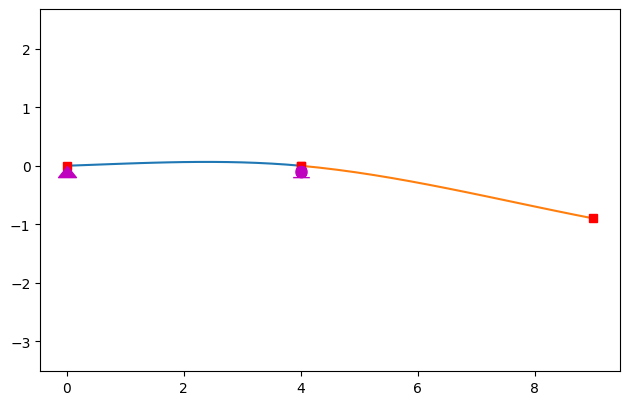

In [160]:

_plot_defo_mode_2d(
    0,  
    sfac,
    nep,
    unDefoFlag,
    fmt_defo,
    fmt_undefo,
    fmt_defo_faces,
    fmt_undefo_faces,
    interpFlag,
    endDispFlag,
    fmt_nodes,
    fig_wi_he,
    fig_lbrt,
    node_supports,
    ax
)


In [161]:
def section_force_distribution_2d(ecrd, pl, nep=2,
                                  ele_load_data=[['-beamUniform', 0., 0.]]):
    """
    Calculate section forces (N, V, M) for an elastic 2D Euler-Bernoulli beam.

    Input:
    ecrd - x, y element coordinates in global system
    nep - number of evaluation points, by default (2) at element ends
    ele_load_list - list of transverse and longitudinal element load
      syntax: [ele_load_type, Wy, Wx]
      For now only '-beamUniform' element load type is acceptable

    Output:
    s = [N V M]; shape: (nep,3)
        section forces at nep points along local x
    xl: coordinates of local x-axis; shape: (nep,)

    Use it with dia_sf to draw N, V, M diagrams.

    nep : int
        number of evaluation points, by default (2) at element ends
        If the element load is between the points then nep is increased by 1 or 2

    TODO: add '-beamPoint' element load type
    """


    Lxy = ecrd[1, :] - ecrd[0, :]
    L = np.sqrt(Lxy @ Lxy)

    nlf = len(pl)
    xl = np.linspace(0., L, nep)

    for ele_load_data_i in ele_load_data:
        ele_load_type = ele_load_data_i[0]

        if nlf == 1:  # trusses
            N_1 = pl[0]
        elif nlf == 6:  # plane frames
            # N_1, V_1, M_1 = pl[0], pl[1], pl[2]
            N_1, V_1, M_1 = pl[:3]
        else:
            print('\nWarning! Not supported. Number of nodal forces: {nlf}')

        if ele_load_type == '-beamUniform':
            # raise ValueError
            # raise NameError

            n_ele_load_data = len(ele_load_data_i)

            if n_ele_load_data == 3:
                # eload_type, Wy, Wx = ele_load_data[0], ele_load_data[1], ele_load_data[2]
                Wy, Wx = ele_load_data_i[1], ele_load_data_i[2]

            elif n_ele_load_data == 7:
                wta, waa, aL, bL, wtb, wab = ele_load_data_i[1:7]
                a, b = aL*L, bL*L

                bma = b - a

                if a in xl:
                    pass
                else:
                    xl = np.insert(xl, xl.searchsorted(a), a)
                    nep += 1
                if b in xl:
                    pass
                else:
                    xl = np.insert(xl, xl.searchsorted(b), b)
                    nep += 1

        elif ele_load_type == '-beamPoint':
            Pt, aL, Pa = ele_load_data_i[1:4]
            a = aL * L

            if a in xl:
                # idx = xl.searchsorted(a)
                # np.concatenate((xl[:idx], [a], xl[idx:]))
                xl = np.insert(xl, xl.searchsorted(a+0.001), a+0.001)
                nep += 1

            else:
                # idx = xl.searchsorted(a)
                # xl = np.concatenate((xl[:idx], [a], xl[idx:]))
                # idx = xl.searchsorted(a+0.001)
                # xl = np.concatenate((xl[:idx], [a+0.001], xl[idx:]))
                xl = np.insert(xl, xl.searchsorted(a), a)
                xl = np.insert(xl, xl.searchsorted(a+0.001), a+0.001)
                nep += 2

    # xl is modified on the fly
    one = np.ones(nep)

    N = -1. * N_1 * one

    if nlf == 6:
        # s = np.zeros((nep, 3))
        V = V_1 * one
        M = -M_1 * one + V_1 * xl
        s = np.column_stack((N, V, M))

    elif nlf == 1:
        # s = np.zeros((nep, 1))
        s = np.column_stack((N))

    for ele_load_data_i in ele_load_data:
        ele_load_type = ele_load_data_i[0]

        if ele_load_type == '-beamUniform':
            # raise ValueError
            # raise NameError

            n_ele_load_data = len(ele_load_data_i)

            if n_ele_load_data == 3:
                # eload_type, Wy, Wx = ele_load_data[0], ele_load_data[1], ele_load_data[2]
                Wy, Wx = ele_load_data_i[1], ele_load_data_i[2]

                N = -1.*(Wx * xl)

                if nlf == 6:
                    V = Wy * xl
                    M = 0.5 * Wy * xl**2
                    s += np.column_stack((N, V, M))
                elif nlf == 1:
                    s += np.column_stack((N))

            elif n_ele_load_data == 7:
                wta, waa, aL, bL, wtb, wab = ele_load_data_i[1:7]
                a, b = aL*L, bL*L

                bma = b - a

                indx = 0
                for x in np.nditer(xl):
                    xma = x - a
                    wtx = wta + (wtb - wta) * xma / bma
                    # xc = a + bma * (wtb + 2*wta) / (3 * (wta + wtb))
                    if wtx == 0:
                        xc = 0.
                    else:
                        xc = xma * (wtx + 2*wta) / (3 * (wta + wtx))

                    Ax = 0.5 * (wtx+wta) * xma
                    # V1x = V_1 * x
                    Axxc = Ax * xc

                    if x < a:
                        pass
                    elif x >= a and x <= b:
                        s[indx, 0] += -1.*((wab - waa) * x)
                        s[indx, 1] += Ax
                        s[indx, 2] += Axxc

                    elif x > b:
                        xmb = x - b
                        xc = bma * (wtb + 2 * wta) / (3 * (wta + wtb)) + xmb
                        Ab = 0.5 * (wtb + wta) * bma
                        Abxc = Ab * xc

                        s[indx, 0] += -1. * ((wab - waa) * x)
                        s[indx, 1] += Ab
                        s[indx, 2] += Abxc

                    indx += 1

                if aL == 0 and bL == 0:
                    N = -1.*(N_1 * one + wta * xl)
                    V = V_1 * one + wta * xl
                else:
                    N = 0

        elif ele_load_type == '-beamPoint':
            Pt, aL, Pa = ele_load_data_i[1:4]
            a = aL * L

            indx = 0
            for x in np.nditer(xl):
                if x <= a:
                    pass
                    # s[indx, 0] += -1. * N_1
                    # s[indx, 1] += V_1
                    # s[indx, 2] += -M_1 + V_1 * x
                elif x > a:
                    s[indx, 0] += -1. * (Pa)
                    s[indx, 1] += Pt
                    s[indx, 2] += Pt * (x-a)

                indx += 1

    # if eload_type == '-beamUniform':
    # else:

    print("s",s," xl",xl," nep",nep)

    return s, xl, nep


In [ ]:

class EleClassTag:
    """ELE_TAG constants defined in SRC/classTags.h"""
    truss = 12
    trussSection = 13
    CorotTruss = 14
    ZeroLength = 19
    ZeroLengthSection = 20
    CoupledZeroLength = 26
    ElasticBeam2d = 3
    ElasticBeam3d = 5
    DispBeamColumn2d = 62
    DispBeamColumn3d = 64
    ForceBeamColumn2d = 73
    ForceBeamColumn3d = 74
    TimoshenkoBeamColumn2d = 63
    TimoshenkoBeamColumn3d = 631
    ElasticTimoshenkoBeam2d = 145
    ElasticTimoshenkoBeam3d = 146
    tri3n = 33
    tri6n = 209
    quad4n = 31
    quad4n3d = 32
    quad9n = 207
    quad8n = 208
    SSPquad = 119
    EnhancedQuad = 59
    brick20n = 49
    brick8n = 56
    SSPbrick = 121
    FourNodeTetrahedron = 179
    TenNodeTetrahedron = 256
    TenNodeTetrahedronSK = 1790
    ASDShellQ4 = 203
    ASDShellT3 = 204
    ShellMITC4 = 53
    ShellMITC9 = 54
    ShellDKGQ = 156
    ShellNLDKGQ = 157
    ShellDKGT = 167
    ShellNLDKGT = 168        
    Joint2D = 82
    Joint3D = 83
    MVLEM = 162
    SFI_MVLEM = 163
    MVLEM_3D = 212
    SFI_MVLEM_3D = 213
    TwoNodeLink = 86
    Pipe = 269
    CurvedPipe = 270

In [162]:
fmt_secforce1 = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '',
                 'markersize': 1, 'solid_capstyle': 'round', 'solid_joinstyle': 'round',
                 'dash_capstyle': 'butt', 'dash_joinstyle': 'round'}
fmt_secforce2 = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 1.0, 'marker': '',
                 'markersize': 1, 'solid_capstyle': 'round', 'solid_joinstyle': 'round',
                 'dash_capstyle': 'butt', 'dash_joinstyle': 'round'}
fmt_secforce_tension = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '', 'markersize': 1}
fmt_secforce_compression = {'color': 'red', 'linestyle': 'solid', 'linewidth': 2.0, 'marker': '', 'markersize': 1}


In [163]:
class LoadTag:
    """LOAD_TAG constants defined in SRC/classTags.h"""
    Beam2dUniformLoad = 3
    Beam2dUniformLoad_ndata = 2

    Beam2dPointLoad = 4
    Beam2dPointLoad_ndata = 3

    Beam3dUniformLoad = 5
    Beam3dUniformLoad_ndata = 3

    Beam3dPointLoad = 6
    Beam3dPointLoad_ndata = 4

    BrickSelfWeight = 7
    Beam2dTempLoad = 8
    SurfaceLoader = 9
    SelfWeight = 10
    Beam2dThermalAction = 11

    Beam2dPartialUniformLoad = 12
    Beam2dPartialUniformLoad_ndata = 6

    Beam3dPartialUniformLoad = 121
    Beam3dPartialUniformLoad_ndata = 5

    Beam3dThermalAction = 13
    ShellThermalAction = 14
    NodalThermalAction = 15
    ThermalActionWrapper = 16
    LysmerVelocityLoader = 17

In [164]:
def get_Ew_data_from_ops_domain():

    Ew = {}
    ibeg = 0
    iend = 0
    ele_load_tags_all_patterns = ops.getEleLoadTags()
    ele_load_types_all_patterns = ops.getEleLoadClassTags()
    ele_load_data_all_patterns = ops.getEleLoadData()

    for ele_load_tag in ele_load_tags_all_patterns:
        Ew[ele_load_tag] = []

    # iterate over ele_load_tags/classtags
    for ele_load_type, ele_load_tag in zip(ele_load_types_all_patterns,
                                           ele_load_tags_all_patterns):

        # -beamUniform
        if ele_load_type == LoadTag.Beam2dUniformLoad:
            iend = ibeg+LoadTag.Beam2dUniformLoad_ndata
            ele_load_data = ele_load_data_all_patterns[ibeg:iend]
            ibeg = iend
            wy, wx = ele_load_data[0], ele_load_data[1]
            Ew[ele_load_tag].append(['-beamUniform', wy, wx])
        # -beamUniform partial
        elif ele_load_type == LoadTag.Beam2dPartialUniformLoad:
            iend = ibeg+LoadTag.Beam2dPartialUniformLoad_ndata
            ele_load_data = ele_load_data_all_patterns[ibeg:iend]
            ibeg = iend
            wta, wtb, waa, wab, aL, bL = ele_load_data
            Ew[ele_load_tag].append(['-beamUniform', wta, waa, aL, bL, wtb, wab])
        # -beamPoint
        elif ele_load_type == LoadTag.Beam2dPointLoad:
            iend = ibeg+LoadTag.Beam2dPointLoad_ndata
            ele_load_data = ele_load_data_all_patterns[ibeg:iend]
            ibeg = iend
            Pt, Pa, aL = ele_load_data
            Ew[ele_load_tag].append(['-beamPoint', Pt, aL, Pa])
        else:
            print(f'\nWarning! ele_load_type:\n{ele_load_type} - Unknown element load Error')


    return Ew

In [165]:
def section_force_diagram_2d(sf_type, sfac=1., nep=17,
                             fmt_secforce1=fmt_secforce1,
                             fmt_secforce2=fmt_secforce2,
                             fig_wi_he=False, fig_lbrt=False,
                             ref_vert_lines=True,
                             end_max_values=True,
                             node_supports=True, ax=False,
                             alt_model_plot=1):
    """Display section forces diagram for 2d beam column model.

    This function plots a section forces diagram for 2d beam column elements
    with or without element loads. For now only '-beamUniform' constant
    transverse or axial element loads are supported.

    Args:
        sf_type (str): type of section force: 'N' - normal force,
            'V' - shear force, 'M' - bending moments.

        sfac (float): scale factor by wich the values of section forces are
            multiplied.

        nep (int): number of evaluation points including both end nodes
            (default: 17)

        fmt_secforce1 (dict): line format dictionary for section force distribution
            curve.

        fmt_secforce2 (dict): line format dictionary for auxiliary reference lines.

        fig_wi_he (tuple): contains width and height of the figure

        fig_lbrt (tuple): a tuple contating left, bottom, right and top offsets

        ref_vert_lines (bool): True means plot the vertical reference lines
            on the section force diagrams.

        end_max_values (bool): True means show the values at element ends and
            extreme (max, min) value between the ends.

        node_supports (bool): True - show the supports.
            Default: True.

        ax: the axes object.

    Returns:
        minVal (float): the minimum overall value of the section force.

        maxVal (float): the maximum overall value of the section force.

        ax: the axes object.

        alt_model_plot (int): 1 - for using the plot_model command,  2 - for using
            simplified model plotting. Other integer - for no model plotting.
            In this case the model can be plotted outside this command
            using the axes (ax) object. Default is 1.

    Usage:
        See example: demo_portal_frame.py
    """

    if not ax:
        if fig_wi_he:
            fig_wi, fig_he = fig_wi_he
            fig, ax = plt.subplots(figsize=(fig_wi/2.54, fig_he/2.54))
        else:
            fig, ax = plt.subplots()

        if fig_lbrt:
            fleft, fbottom, fright, ftop = fig_lbrt
            fig.subplots_adjust(left=fleft, bottom=fbottom, right=fright, top=ftop)

    if alt_model_plot == 1:
        ax = opsv.model.plot_model(node_labels=0, element_labels=0,
                              fmt_model=fmt_model_secforce,
                              node_supports=False,
                              fmt_model_truss=fmt_model_secforce,
                              truss_node_offset=0, ax=ax)
    else:
        pass

    fmt_secforce1_orig = fmt_secforce1
    maxVal, minVal = -np.inf, np.inf

    ele_tags = ops.getEleTags()

    Ew = get_Ew_data_from_ops_domain()
    print("Ew",Ew)

    for ele_tag in ele_tags:

        ele_class_tag = ops.getEleClassTags(ele_tag)[0]

        if (ele_class_tag == EleClassTag.ElasticBeam2d
            or ele_class_tag == EleClassTag.ForceBeamColumn2d
            or ele_class_tag == EleClassTag.DispBeamColumn2d
            or ele_class_tag in [EleClassTag.truss, EleClassTag.trussSection]
            or ele_class_tag == EleClassTag.TimoshenkoBeamColumn2d
            or ele_class_tag == EleClassTag.ElasticTimoshenkoBeam2d):

            ele_node_tags = ops.eleNodes(ele_tag)
            ecrd = np.zeros((2, 2))
            for i, ele_node_tag in enumerate(ele_node_tags):
                ecrd[i, :] = ops.nodeCoord(ele_node_tag)

            Lxy = ecrd[1, :] - ecrd[0, :]
            L = np.sqrt(Lxy @ Lxy)
            cosa, cosb = Lxy / L

            if ele_class_tag in [EleClassTag.truss, EleClassTag.trussSection]:
                if sf_type == 'N' or sf_type == 'axial':
                    axial_force = ops.eleResponse(ele_tag, 'axialForce')[0]
                    ss = -axial_force * np.ones(nep)
                    xl = np.linspace(0., L, nep)

                    if axial_force > 0:
                        va = 'top'
                        fmt_color = 'b'
                        fmt_secforce1 = fmt_secforce_tension
                    else:
                        va = 'bottom'
                        fmt_color = 'r'
                        fmt_secforce1 = fmt_secforce_compression

                else:  # for sf_type = 'V' or 'M'
                    xl = np.linspace(0., L, 2)
                    ss = np.zeros(2)

            else:  # for other elements than truss
                # by default no element load
                eload_data = [['-beamUniform', 0., 0.]]
                if ele_tag in Ew:
                    eload_data = Ew[ele_tag]

                pl = ops.eleResponse(ele_tag, 'localForces')

                # rigid offsets for 2d
                ele_offsets = np.array(ops.eleResponse(ele_tag, 'offsets'))
                nz_offsets = np.nonzero(ele_offsets)[0]  # tuple of arrays
                if np.any(nz_offsets):
                    # modify ecrd_eles
                    # ex += ele_offsets[[0, 3]]
                    # ey += ele_offsets[[1, 4]]
                    ecrd[:, 0] += ele_offsets[[0, 3]]
                    ecrd[:, 1] += ele_offsets[[1, 4]]
                    # modify the following due to rigid offsets
                    # Lxy = np.array([ex[1]-ex[0], ey[1]-ey[0]])
                    Lxy = ecrd[1, :] - ecrd[0, :]
                    L = np.sqrt(Lxy @ Lxy)
                    cosa, cosb = Lxy / L
                else:
                    pass
                print("pl",pl)
                print("eload_data",eload_data)
                s_all, xl, nep = section_force_distribution_2d(ecrd, pl, nep, eload_data)

                if sf_type == 'N' or sf_type == 'axial':
                    ss = s_all[:, 0]
                elif sf_type == 'V' or sf_type == 'shear' or sf_type == 'T':
                    ss = s_all[:, 1]
                elif sf_type == 'M' or sf_type == 'moment':
                    ss = s_all[:, 2]

            if len(ss) == 2:  # for truss with zero shear force and moment
                pass

            else:
                # minVal = min(minVal, np.min(ss))
                # maxVal = max(maxVal, np.max(ss))
                minVal, minVal_ind = np.amin(ss), np.argmin(ss)
                maxVal, maxVal_ind = np.amax(ss), np.argmax(ss)

                s = ss * sfac

                s_0 = np.zeros((nep, 2))
                s_0[0, :] = [ecrd[0, 0], ecrd[0, 1]]

                s_0[1:, 0] = s_0[0, 0] + xl[1:] * cosa
                s_0[1:, 1] = s_0[0, 1] + xl[1:] * cosb

                s_p = np.copy(s_0)

                # positive M are opposite to N and V
                if sf_type == 'M' or sf_type == 'moment':
                    s *= -1.

                s_p[:, 0] -= s * cosb
                s_p[:, 1] += s * cosa

                ax.axis('equal')

                # section force curve
                ax.plot(s_p[:, 0], s_p[:, 1], **fmt_secforce1)
                fmt_secforce1 = fmt_secforce1_orig

                # reference perpendicular lines
                if ref_vert_lines:
                    for i in np.arange(nep):
                        ax.plot([s_0[i, 0], s_p[i, 0]], [s_0[i, 1], s_p[i, 1]],
                                **fmt_secforce2)
                else:
                    ax.plot([s_0[0, 0], s_p[0, 0]], [s_0[0, 1], s_p[0, 1]],
                            **fmt_secforce2)
                    ax.plot([s_0[-1, 0], s_p[-1, 0]], [s_0[-1, 1], s_p[-1, 1]],
                            **fmt_secforce2)

            if ele_class_tag in [EleClassTag.truss, EleClassTag.trussSection]:
                ha = 'center'
                va = 'bottom'
                if sf_type == 'N' or sf_type == 'axial':
                    ax.text(s_p[int(nep / 2), 0], s_p[int(nep / 2), 1],
                            f'{abs(axial_force):.1f}', va=va, ha=ha, color=fmt_color)
                # else:
                #     ax.text(s_p[int(nep / 2), 0], s_p[int(nep / 2), 1],
                #             '0.0', va=va, ha=ha)

            else:
                if end_max_values:
                    ha = 'left'
                    va = 'bottom'
                    ax.text(s_p[0, 0], s_p[0, 1],
                            f'{ss[0]:.5g}', va=va, ha=ha)
                    ax.text(s_p[-1, 0], s_p[-1, 1],
                            f'{ss[-1]:.5g}', va=va, ha=ha)

                    if minVal_ind != 0 or minVal_ind != nep - 1:
                        ax.text(s_p[minVal_ind, 0], s_p[minVal_ind, 1],
                                f'{ss[minVal_ind]:.5g}', va=va, ha=ha)

                    if maxVal_ind != 0 or maxVal_ind != nep - 1:
                        ax.text(s_p[maxVal_ind, 0], s_p[maxVal_ind, 1],
                                f'{ss[maxVal_ind]:.5g}', va=va, ha=ha)

    if node_supports:
        node_tags = ops.getNodeTags()
        ax = opsv.model._plot_supports(node_tags, ax)

    # ax.grid(False)

    return minVal, maxVal, ax

Ew {2: [['-beamUniform', -2000.0, 0.0, 0.2, 0.9, -4000.0, 0.0]], 1: [['-beamUniform', -2000.0, 0.0]]}
pl [0.0, -1229.166666666666, 2.2737367544323206e-12, 0.0, 9229.166666666666, -20916.666666666668]
eload_data [['-beamUniform', -2000.0, 0.0]]
s [[-0.00000000e+00 -1.22916667e+03 -2.27373675e-12]
 [-0.00000000e+00 -1.72916667e+03 -3.69791667e+02]
 [-0.00000000e+00 -2.22916667e+03 -8.64583333e+02]
 [-0.00000000e+00 -2.72916667e+03 -1.48437500e+03]
 [-0.00000000e+00 -3.22916667e+03 -2.22916667e+03]
 [-0.00000000e+00 -3.72916667e+03 -3.09895833e+03]
 [-0.00000000e+00 -4.22916667e+03 -4.09375000e+03]
 [-0.00000000e+00 -4.72916667e+03 -5.21354167e+03]
 [-0.00000000e+00 -5.22916667e+03 -6.45833333e+03]
 [-0.00000000e+00 -5.72916667e+03 -7.82812500e+03]
 [-0.00000000e+00 -6.22916667e+03 -9.32291667e+03]
 [-0.00000000e+00 -6.72916667e+03 -1.09427083e+04]
 [-0.00000000e+00 -7.22916667e+03 -1.26875000e+04]
 [-0.00000000e+00 -7.72916667e+03 -1.45572917e+04]
 [-0.00000000e+00 -8.22916667e+03 -1.655

(np.float64(-20916.666666666668), np.float64(1500.162760416666), <Axes: >)

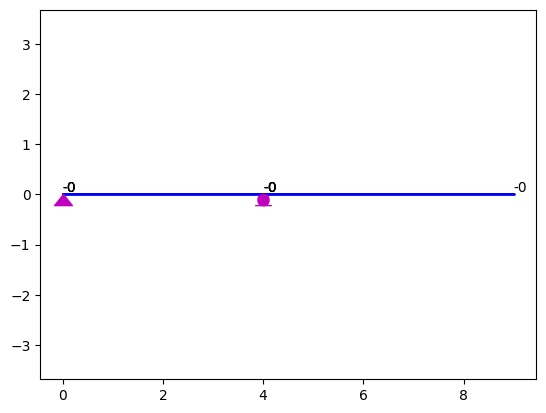

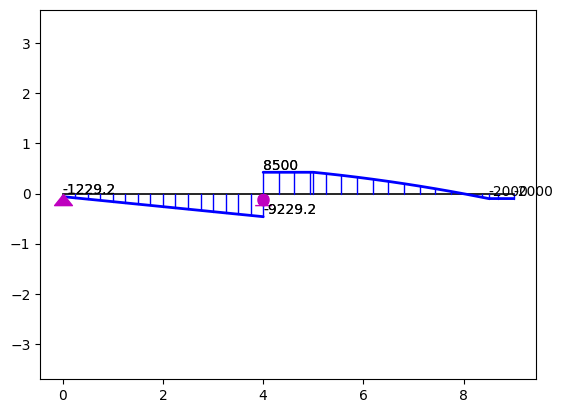

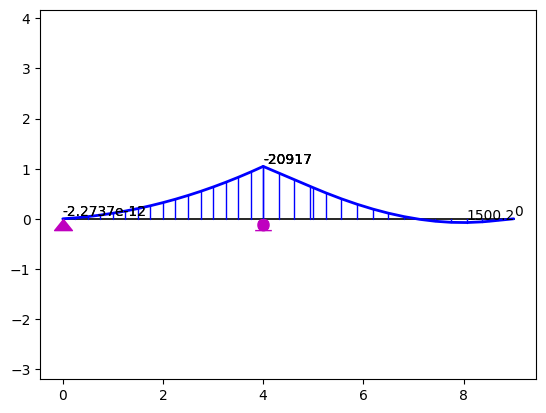

In [166]:
sfacN, sfacV, sfacM = 5.e-5, 5.e-5, 5.e-5

section_force_diagram_2d('N', sfacN)
section_force_diagram_2d('T', sfacV)
section_force_diagram_2d('M', sfacM)